In [2]:
# %pip install simple-icd-10

In [3]:
# %pip install seaborn

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import pandas as pd
import json
import re
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import simple_icd_10 as icd
from parsing import safe_parse, get_key, parse_codes, n_bad_codes

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

In [5]:
# MODEL = "qwen3-235b-a22b_0"
# MODEL = "GPT_OSS_MODEL_SIZE.BIG_Low_0"
MODEL = "GPT_OSS_MODEL_SIZE.SMALL_Low_w_rnd_lvl_0"
RESPONSES_PATH = f"outputs/responses_{MODEL}.tsv"

In [7]:
responses = pd.read_csv(RESPONSES_PATH, sep="\t")

In [8]:
responses.shape

(1696, 2)

### parsing json

In [9]:
responses.loc[0, "response"]

'{\n  "comment": "Patients with other liver diseases (K76) often have underlying or related hepatic conditions such as alcoholic liver disease (K70), toxic liver disease (K71), hepatitis (K72), chronic liver disease (K73), and cirrhosis (K74). These categories are strongly associated with K76 and therefore more likely to co‑occur than in a random patient.",\n  "answer": {\n    "B": ["K70", "K71", "K72", "K73", "K74"],\n    "C": []\n  }\n}'

In [10]:
responses["codes"] = responses["response"].apply(lambda x: get_key(x, "answer"))
# responses["codes"] = responses["response"].apply(lambda x: safe_parse(x, "answer"))

Expecting ',' delimiter: line 5 column 846 (char 1994)
{
  "comment": "Patients with secondary malignant neoplasm of lymph nodes (C77) almost always have a primary malignancy elsewhere, so other malignant neoplasm categories (C00‑C97) and secondary sites (C78, C79) are far more common than in a random patient. Conversely, benign neoplasms (D00‑D48) and many non‑neoplastic disease categories (e.g., E00‑E89 endocrine disorders, F00‑F99 mental disorders) are less frequently seen in this population, as the clinical focus is on cancer staging and treatment rather than these conditions.",
  "answer": {
    "B": ["C00","C01","C02","C03","C04","C05","C06","C07","C08","C09","C10","C11","C12","C13","C14","C15","C16","C17","C18","C19","C20","C21","C22","C23","C24","C25","C26","C27","C28","C29","C30","C31","C32","C33","C34","C35","C36","C37","C38","C39","C40","C41","C42","C43","C44","C45","C46","C47","C48","C49","C50","C51","C52","C53","C54","C55","C56","C57","C58","C59","C60","C61","C62","C63","C

In [11]:
len(responses[responses["codes"].isna()])

7

In [12]:
responses[responses["codes"].isna()]

,Unnamed: 0,response,codes
211,C77,"{\n ""comment"": ""Patients with secondary malig...",None
770,M30,"{""comment"":""Polyarteritis nodosa (M30) is a sy...",None
805,E56,"{\n ""comment"": ""Vitamin deficiencies (E56) ar...",None
1116,X93,"```json\n{\n ""comment"": ""Patients who have su...",None
1542,P01,"{\n ""comment"": ""Patients with a P01 diagnosis...",None
1576,X74,"```json\n{\n ""comment"": ""Patients with intent...",None
1671,A82,"```json\n{\n ""comment"": ""Rabies is a rare zoo...",None


In [13]:
responses.dropna(axis=0, subset=["codes"], inplace=True)

In [14]:
responses.sample(10)

,Unnamed: 0,response,codes
1564,W90,"{\n ""comment"": ""Exposure to non‑ionizing radi...","{'B': ['L23', 'M75'], 'C': ['C50', 'H25']}"
773,Q54,"```json\n{\n ""comment"": ""Hypospadias is a con...","{'B': ['Q60', 'Q61', 'Q65', 'Q20'], 'C': ['K70..."
334,D47,"{\n ""comment"": ""Patients with neoplasms of un...","{'B': ['D50', 'D51', 'D52', 'D53', 'D55', 'D56..."
1437,D82,"{\n ""comment"": ""Patients with D82 (immunodefi...","{'B': ['J00', 'J99', 'B20', 'B24', 'D80', 'D84..."
459,E44,"{\n ""comment"": ""Patients with moderate/mild p...","{'B': ['E45', 'E46', 'E47'], 'C': ['E66']}"
1438,F04,"```json\n{\n ""comment"": ""Patients with organi...","{'B': ['G30', 'I63', 'F32', 'G40'], 'C': ['B20..."
1330,C07,"{\n ""comment"": ""Patients with malignant parot...","{'B': ['C00-C14'], 'C': ['H60-H69']}"
1197,J33,"{\n ""comment"": ""Nasal polyps (J33) are strong...","{'B': ['J45', 'J30', 'J01', 'K21'], 'C': ['C34..."
1270,O67,"```json\n{\n ""comment"": ""Patients with intrap...","{'B': ['D64', 'D69', 'D65', 'A41'], 'C': ['I20..."
1621,A50,"{\n ""comment"": ""Congenital syphilis is a sexu...","{'B': ['B20', 'A54'], 'C': ['M00', 'C00']}"


In [15]:
responses["type"] = responses["codes"].apply(lambda x: str(type(x)))

In [16]:
responses[responses["type"] != "<class 'dict'>"]

,Unnamed: 0,response,codes,type


In [17]:
responses["B"] = responses["codes"].apply(lambda x: x.get("B", []))
responses["C"] = responses["codes"].apply(lambda x: x.get("C", []))

### parsing codes in string

In [18]:
# global n_bad_codes
# n_bad_codes = 0
for answer in ["B", "C"]:
    responses[f"{answer}_ready"] = responses[answer].apply(parse_codes)

print(f"Number of bad codes: {n_bad_codes}") # defined as global in parsing.py

R57.3 is not ICD-10 item
R57.4 is not ICD-10 item
R57.5 is not ICD-10 item
R57.6 is not ICD-10 item
R57.7 is not ICD-10 item
R07.9 is not ICD-10 item
Z79.4 is not ICD-10 item
I84 is not ICD-10 item
K32 is not ICD-10 item
K33 is not ICD-10 item
K34 is not ICD-10 item
K39 is not ICD-10 item
Q08 is not ICD-10 item
Q09 is not ICD-10 item
Q19 is not ICD-10 item
Q29 is not ICD-10 item
Q46 is not ICD-10 item
Q47 is not ICD-10 item
Q48 is not ICD-10 item
Q49 is not ICD-10 item
Q57 is not ICD-10 item
Q58 is not ICD-10 item
Q59 is not ICD-10 item
Q88 is not ICD-10 item
Q94 is not ICD-10 item
I84 is not ICD-10 item
G89 is not ICD-10 item
C27 is not ICD-10 item
C28 is not ICD-10 item
C29 is not ICD-10 item
C35 is not ICD-10 item
C36 is not ICD-10 item
C42 is not ICD-10 item
C59 is not ICD-10 item
C87 is not ICD-10 item
C89 is not ICD-10 item
C27 is not ICD-10 item
C28 is not ICD-10 item
C29 is not ICD-10 item
C35 is not ICD-10 item
C36 is not ICD-10 item
C42 is not ICD-10 item
C59 is not ICD-10 it

In [19]:
responses.head()

,Unnamed: 0,response,codes,type,B,C,B_ready,C_ready
0,K76,"{\n ""comment"": ""Patients with other liver dis...","{'B': ['K70', 'K71', 'K72', 'K73', 'K74'], 'C'...",<class 'dict'>,"[K70, K71, K72, K73, K74]",[],"[K73, K72, K71, K74, K70]",[]
1,R18,"```json\n{\n ""comment"": ""Ascites is most comm...","{'B': ['K70', 'K74', 'K76', 'I85', 'I86', 'C22...",<class 'dict'>,"[K70, K74, K76, I85, I86, C22]","[A00, J45, I10]","[K76, K74, I85, I86, K70, C22]","[I10, J45, A00]"
2,K74,"{\n ""comment"": ""Patients with liver fibrosis/...","{'B': ['K70', 'K73', 'K75', 'K76', 'I85', 'I83...",<class 'dict'>,"[K70, K73, K75, K76, I85, I83, E83, N18]","[A00, A01, A02, A03, A04, A05, A06, A07, A08, ...","[K73, K76, K75, I85, I83, N18, E83, K70]","[A09, A01, A05, A06, A04, A07, A02, A03, A08, ..."
3,B19,"{\n ""comment"": ""Patients with unspecified vir...","{'B': ['B15', 'B18', 'B21', 'C22'], 'C': ['C34']}",<class 'dict'>,"[B15, B18, B21, C22]",[C34],"[B18, C22, B15, B21]",[C34]
4,J44,"{\n ""comment"": ""Patients with chronic obstruc...","{'B': ['I25', 'I10', 'J45', 'R06', 'J43'], 'C'...",<class 'dict'>,"[I25, I10, J45, R06, J43]",[G47],"[R06, J45, J43, I10, I25]",[G47]


In [20]:
all_codes = set(responses["Unnamed: 0"].values)

for answer in ["B", "C"]:
    for codes in tqdm(responses[f"{answer}_ready"]):
        all_codes = all_codes.union(set(codes))
    
all_codes = sorted(list(all_codes))

100%|██████████| 1689/1689 [00:00<00:00, 57634.78it/s]


In [21]:
for answer in ["B", "C"]:
    for codes in tqdm(responses[f"{answer}_ready"]):
        for code in set(codes):
            if code not in all_codes: #avoid duplicates
                all_codes.append(code)
            
all_codes = sorted(list(all_codes))

100%|██████████| 1689/1689 [00:00<00:00, 11079.82it/s]


In [22]:
len(all_codes)

1948

In [23]:
scores = pd.DataFrame(data = np.zeros((len(all_codes), len(all_codes))), index=sorted(list(all_codes)), columns=sorted(list(all_codes)))

In [24]:
for _, row in tqdm(responses.iterrows()):
    for answer in ["B", "C"]:
        for code in row[f"{answer}_ready"]:
            if answer == "B":
                scores.loc[row["Unnamed: 0"], code] += 1
            elif answer == "C":
                scores.loc[row["Unnamed: 0"], code] -= 1
            else:
                raise ValueError("Invalid answer {}".format(answer))

0it [00:00, ?it/s]

1689it [00:04, 356.73it/s]


<Axes: ylabel='Count'>

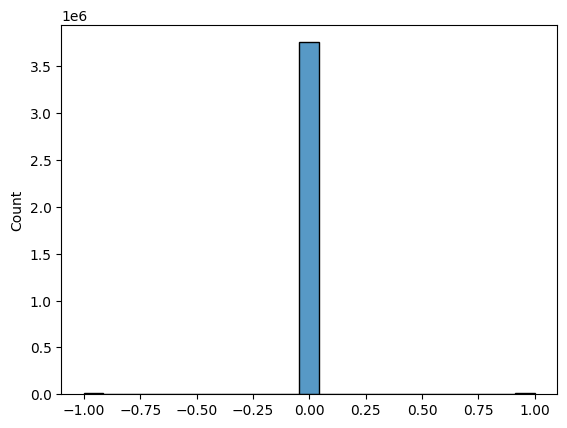

In [25]:
sns.histplot(scores.values.flatten())

In [26]:
vals, bins = np.histogram(scores.values.flatten(), bins=np.arange(-10, 10, 1))
pd.DataFrame({"bins": bins[:-1], "counts": vals})

,bins,counts
0,-10,0
1,-9,0
2,-8,0
3,-7,0
4,-6,0
5,-5,0
6,-4,0
7,-3,0
8,-2,0
9,-1,18724


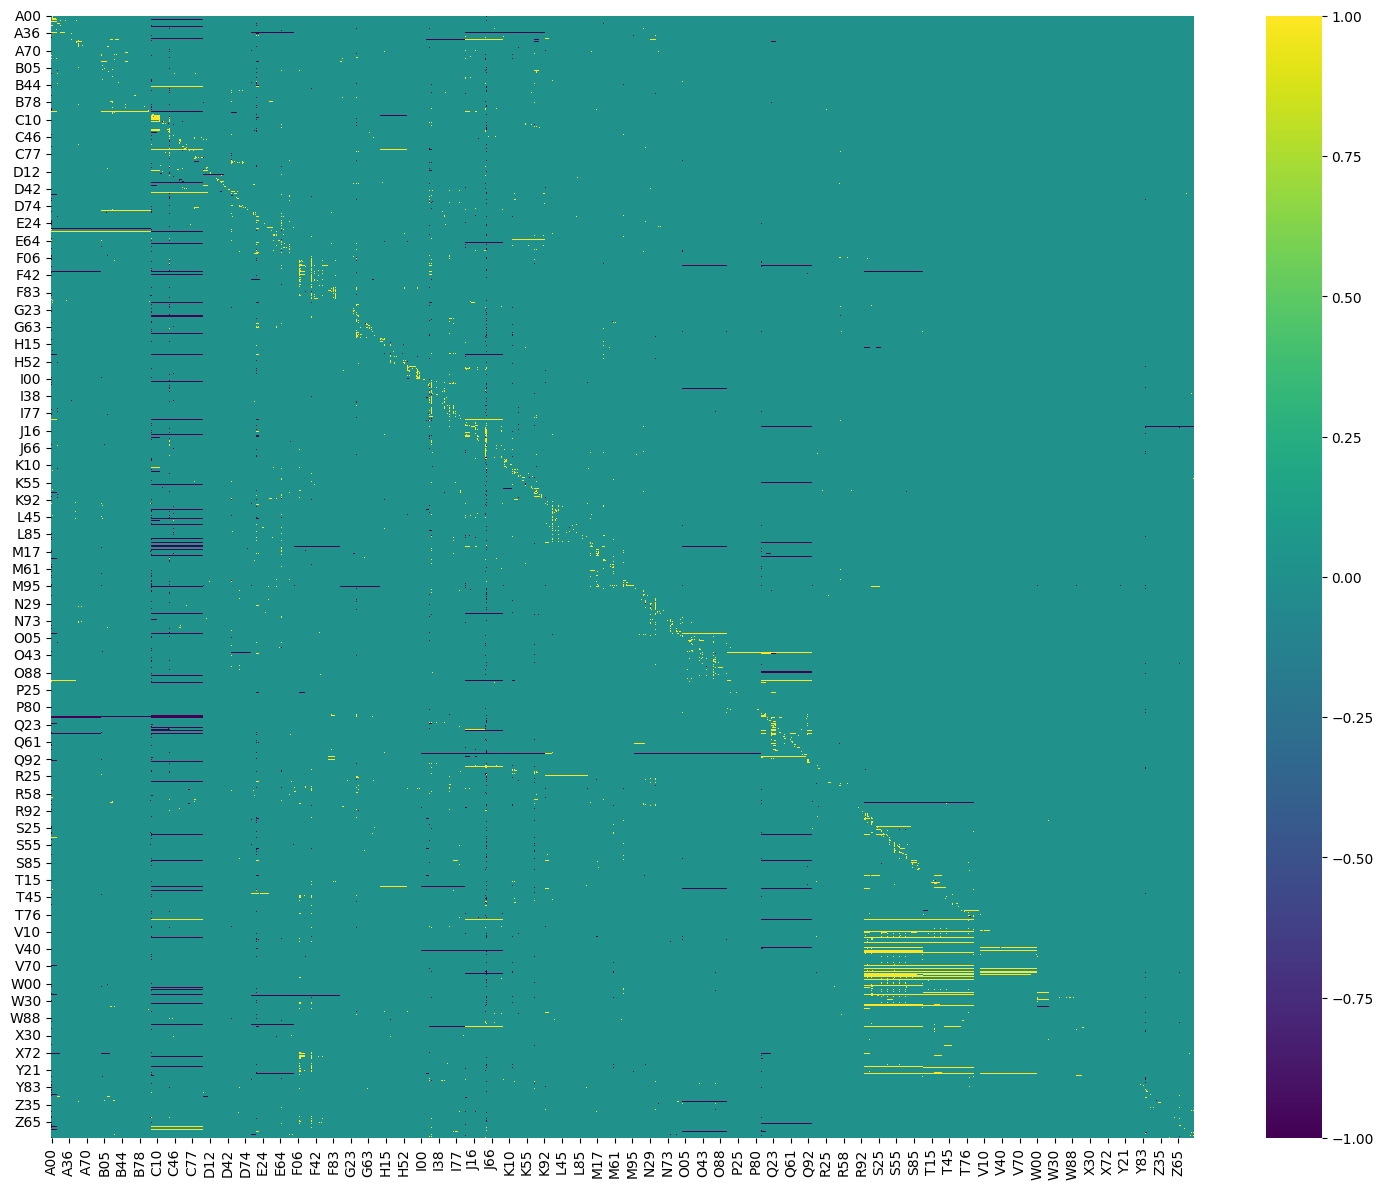

In [27]:
plt.figure(figsize=(15, 12))
sns.heatmap(scores, cmap ='viridis')
plt.tight_layout()
if not os.path.exists("pics/"): os.makedirs("pics/")
plt.savefig(f"pics/{MODEL}_forward.png", dpi=300, bbox_inches='tight')
plt.show()

In [28]:
if not os.path.exists("scores/"): os.makedirs("scores/")
scores.to_csv(f"scores/scores_{MODEL}_forward.csv")

### symmetrization

In [2]:
scores = (scores + scores.T)/2

NameError: name 'scores' is not defined

In [1]:
vals, bins = np.histogram(scores.values.flatten(), bins=np.arange(-10, 10, 1))
pd.DataFrame({"bins": bins[:-1], "counts": vals})

NameError: name 'np' is not defined

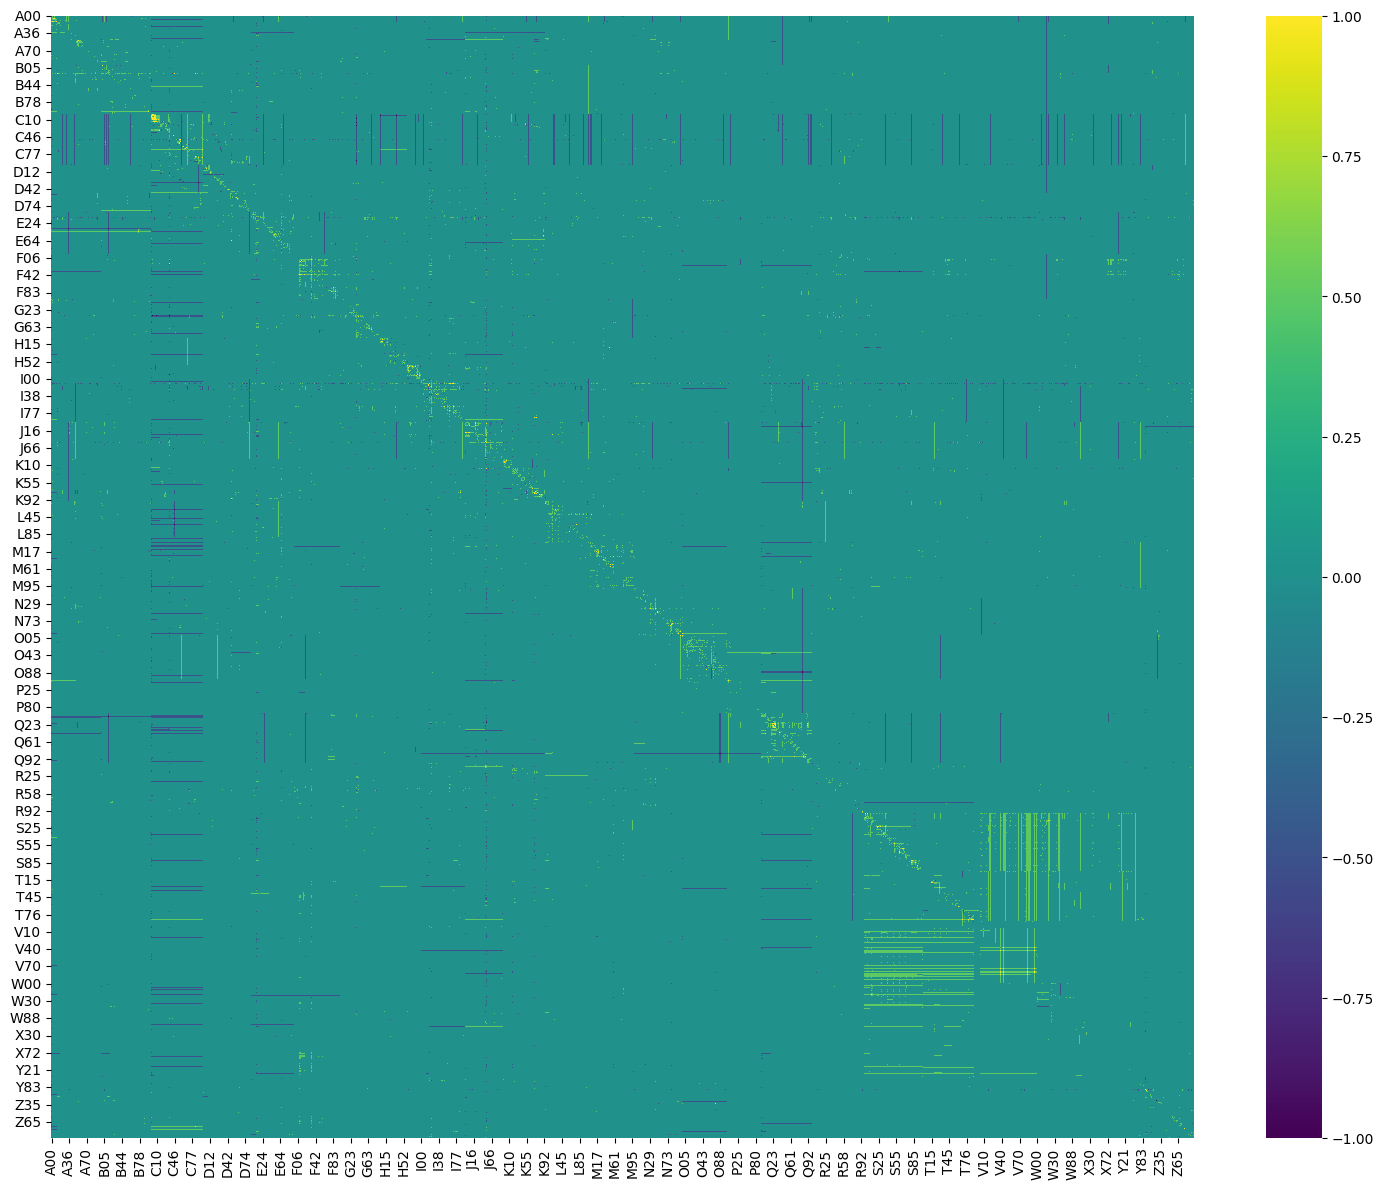

In [30]:
plt.figure(figsize=(15, 12))
sns.heatmap(scores, cmap ='viridis')
plt.tight_layout()
if not os.path.exists("pics/"): os.makedirs("pics/")
plt.savefig(f"pics/{MODEL}.png", dpi=300, bbox_inches='tight')
plt.show()

In [31]:
if not os.path.exists("scores/"): os.makedirs("scores/")
scores.to_csv(f"scores/scores_{MODEL}.csv")